**Project Overview**
This project analyzes U.S. avocado market data to understand *pricing trends, demand patterns, and regional differences* across time and product types (organic vs. conventional). The goal is to extract *actionable insights* that could inform *pricing strategy, inventory planning, and market analysis*.

**key Business Questions**
 * How do *prices and sales volumes* vary over time?
 * What differences exist between *organic and conventional* avocados?
 * Which regions exhibit consistently higher or lower prices?
 * Are there observable *trends or patterns* in demand and bag sizes?

**Approach**
 * Data loading, cleaning, and feature creation
 * Exploratory data analysis using aggregations and statistics
 * Visualization of trends by year, region, and product type

**Libaray used**

Python · Pandas · Matplotlib · Seaborn

**Key Takeaways**
 * Organic avocados consistently command higher prices.
 * Sales volume and demand patterns vary meaningfully across years and regions.
 * Regional pricing differences suggest distinct market dynamics.

In [2]:
import pandas as pd
df = pd.read_csv('avocado.csv')
df

,Date,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,12/27/2015,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...
18244,2/4/2018,1.63,17074.83,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,1/28/2018,1.71,13888.04,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,1/21/2018,1.87,13766.76,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,1/14/2018,1.93,16205.22,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  object 
 1   AveragePrice  18249 non-null  float64
 2   Total Volume  18249 non-null  float64
 3   Total Bags    18249 non-null  float64
 4   Small Bags    18249 non-null  float64
 5   Large Bags    18249 non-null  float64
 6   XLarge Bags   18249 non-null  float64
 7   type          18249 non-null  object 
 8   year          18249 non-null  int64  
 9   region        18249 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 1.4+ MB


In [3]:
df.nunique()

Date              169
AveragePrice      259
Total Volume    18237
Total Bags      18097
Small Bags      17321
Large Bags      15082
XLarge Bags      5588
type                2
year                4
region             54
dtype: int64

In [5]:
df.head(5) # display first 5 rows

,Date,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,12/27/2015,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [6]:
df.tail(5) # display last 5 rows

,Date,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
18244,2/4/2018,1.63,17074.83,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,1/28/2018,1.71,13888.04,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,1/21/2018,1.87,13766.76,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,1/14/2018,1.93,16205.22,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico
18248,1/7/2018,1.62,17489.58,12014.15,11988.14,26.01,0.0,organic,2018,WestTexNewMexico


In [7]:
df.iloc[:, :4] # display first 5 columns


,Date,AveragePrice,Total Volume,Total Bags
0,12/27/2015,1.33,64236.62,8696.87
1,12/20/2015,1.35,54876.98,9505.56
2,12/13/2015,0.93,118220.22,8145.35
3,12/6/2015,1.08,78992.15,5811.16
4,11/29/2015,1.28,51039.60,6183.95
...,...,...,...,...
18244,2/4/2018,1.63,17074.83,13498.67
18245,1/28/2018,1.71,13888.04,9264.84
18246,1/21/2018,1.87,13766.76,9394.11
18247,1/14/2018,1.93,16205.22,10969.54


In [8]:
df.iloc[:, -4:] # display last 5 columns

,XLarge Bags,type,year,region
0,0.0,conventional,2015,Albany
1,0.0,conventional,2015,Albany
2,0.0,conventional,2015,Albany
3,0.0,conventional,2015,Albany
4,0.0,conventional,2015,Albany
...,...,...,...,...
18244,0.0,organic,2018,WestTexNewMexico
18245,0.0,organic,2018,WestTexNewMexico
18246,0.0,organic,2018,WestTexNewMexico
18247,0.0,organic,2018,WestTexNewMexico


In [9]:
df.describe()

,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,0.402677,3.453545e+06,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.100000,1.083858e+04,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,1.370000,1.073768e+05,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,1.660000,4.329623e+05,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,3.250000,6.250565e+07,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [10]:
df['EstimatedRevenue']  = df['AveragePrice'] * df['Total Volume']
df.head()

,Date,AveragePrice,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,EstimatedRevenue
0,12/27/2015,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,85434.7046
1,12/20/2015,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,74083.9230
2,12/13/2015,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,109944.8046
3,12/6/2015,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,85311.5220
4,11/29/2015,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,65330.6880


In [6]:
#confirm problem question prompt matching my answer
grouped_df = df.groupby(['region', 'type'])['AveragePrice'].mean().reset_index()
grouped_df.head()

,region,type,AveragePrice
0,Albany,conventional,1.348757
1,Albany,organic,1.773314
2,Atlanta,conventional,1.068817
3,Atlanta,organic,1.607101
4,BaltimoreWashington,conventional,1.344201


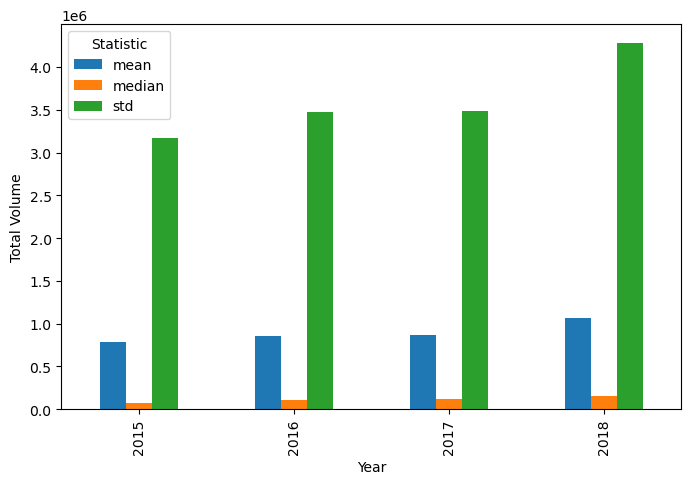

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#df_mean = df[['year', 'Total Volume']].groupby('year').mean()
#df_median = df[['year', 'Total Volume']].groupby('year').median()
#df_std = df[['year', 'Total Volume']].groupby('year').std()

#combined_df = pd.concat([df_mean, df_median, df_std])

#agg_df = df[['year', 'Total Volume']].groupby('year').agg(['mean', 'median','std'].reset_index())
#type(agg_df)

volume_stats = (
    df.groupby('year')['Total Volume']
      .agg(['mean', 'median', 'std'])
      .reset_index()
)
volume_stats

volume_stats.plot(
    x='year',
    y=['mean', 'median', 'std'],
    kind='bar',
    figsize=(8,5)
)

plt.xlabel('Year')
plt.ylabel('Total Volume')
plt.legend(title='Statistic')
#sns.catplot(data= agg_df.query('year in(2015, 2016, 2017, 2018)'), kind ='bar', x ='year', y='Total Volume')
#need to fix bar chart

In [8]:
df['region'].nunique()

54

In [8]:
#df[['type','AveragePrice']].groupby('type').mean()
#this also works

avg_price_by_type = (
    df.groupby('type')['AveragePrice']
      .mean()
      .reset_index()
)
avg_price_by_type

,type,AveragePrice
0,conventional,1.158040
1,organic,1.653999


In [9]:

#df_dropped = df.drop(df[df['type'] == 'conventional'].index)
#region_mean = df_dropped[['region', 'AveragePrice']].groupby('region').mean()
#print(region_mean.idxmean())  # is printing weird, need better format


organic_df = df[df['type'] == 'organic']

avg_price_by_region = (
    organic_df.groupby('region')['AveragePrice']
              .mean()
              .reset_index()
)

lowest_price_region = avg_price_by_region.sort_values('AveragePrice', ascending=True).head(1)
lowest_price_region

,region,AveragePrice
18,Houston,1.270769


In [10]:
#total_bags_sold = df[['year','Total Bags']].groupby('year').sum()
#why doesn't below work?
#agg_data = df.groupby(['year','Total Bags','type']).sum()
#consistency = df.groupby(['year', 'type'])['Total Bags'].agg(['mean', 'std']).reset_index()
#consistency

bags_per_year = (
    df.groupby(['year', 'type'])['Total Bags']
      .sum()
      .reset_index()
)
bags_per_year.head()

consistency_check = (
    bags_per_year.groupby('type')['Total Bags']
                 .std()
                 .reset_index()
                 .rename(columns={'Total Bags':'StdDev_TotalBags'})
)
consistency_check


,type,StdDev_TotalBags
0,conventional,5.169537e+08
1,organic,3.686566e+07


In [11]:
initial_rows = len(df)
dropped_region = df.set_index('region').drop(['TotalUS'])
cleanned_rows = len(dropped_region)
dropped_rows = initial_rows - cleanned_rows
print(f"Number of rows after dropping: {dropped_rows}")


Number of rows after dropping: 338


In [12]:
#df_dict = {'Date' : 'Date', 
#           'Average Price': 'AveragePrice', 
#           'Total Volume': 'TotalVolume',
#           'Total Bags': 'TotalBags',
#           'Small Bags':'SmallBags',
#           'Large Bags':'LargeBags',
#           'XLarge Bags':'XLargeBags',
#           'type' : 'type',
#           'year': 'year',
#           'region' : 'region'}
#need to check
import re

def spaced(name: str) -> str:
    # add space only between a-z/0-9 and next A-Z (camelCase/TitleCase boundary)
    s = re.sub(r'(?<=[a-z0-9])(?=[A-Z])', ' ', name)
    # collapse any repeated whitespace and trim
    return re.sub(r'\s+', ' ', s).strip()

# dictionary comprehension: map old -> nicely spaced
rename_map = {col: spaced(col) for col in df.columns}

df.rename(columns=rename_map, inplace=True)
df.head()

,Date,Average Price,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,12/27/2015,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [13]:
#also work
#df.groupby(['region', 'year', 'type'])['Total Bags'].agg(['sum'])


# Group by region, year, and type, then sum the Total Bags
grouped = (
    df.groupby(['region', 'year', 'type'])['Total Bags']
      .sum()
      .unstack('type')      # makes 'type' (conventional/organic) into columns
      .fillna(0)            # replace missing values with 0
)

# Rename the axis for clarity
grouped.columns.name = 'Type'
grouped.index.names = ['Region', 'Year']

grouped


Type                   conventional     organic
Region           Year                          
Albany           2015     662366.17    57289.43
                 2016     759091.14    79208.77
                 2017     699561.17   135944.43
                 2018     245240.75    41552.75
Atlanta          2015    2935925.63    61065.24
...                             ...         ...
West             2018   35978608.70  2074684.34
WestTexNewMexico 2015    5399316.40   128763.94
                 2016   10870856.07   403881.08
                 2017   14195031.44   602152.24
                 2018    3547372.46   149141.90

[216 rows x 2 columns]

In [14]:
df['Date'] = pd.to_datetime(df['Date'])
#print(df.dtypes)
year_2015 = df.query('year == 2015 and type == "conventional" and region == "Albany"')
#year_2015
new_column = ['Date', 'Total Bags', 'Small Bags']
cleanned_data = pd.DataFrame(data = year_2015, columns = new_column)
cleanned_data.head()
#type(cleanned_data)

,Date,Total Bags,Small Bags
0,2015-12-27,8696.87,8603.62
1,2015-12-20,9505.56,9408.07
2,2015-12-13,8145.35,8042.21
3,2015-12-06,5811.16,5677.40
4,2015-11-29,6183.95,5986.26


In [15]:
bag_melted = pd.melt(df, id_vars = 'Date',
        value_vars = ['Total Bags', 'Small Bags'],
        var_name = 'Bags', value_name = 'Count')
bag_melted


,Date,Bags,Count
0,2015-12-27,Total Bags,8696.87
1,2015-12-20,Total Bags,9505.56
2,2015-12-13,Total Bags,8145.35
3,2015-12-06,Total Bags,5811.16
4,2015-11-29,Total Bags,6183.95
...,...,...,...
36493,2018-02-04,Small Bags,13066.82
36494,2018-01-28,Small Bags,8940.04
36495,2018-01-21,Small Bags,9351.80
36496,2018-01-14,Small Bags,10919.54


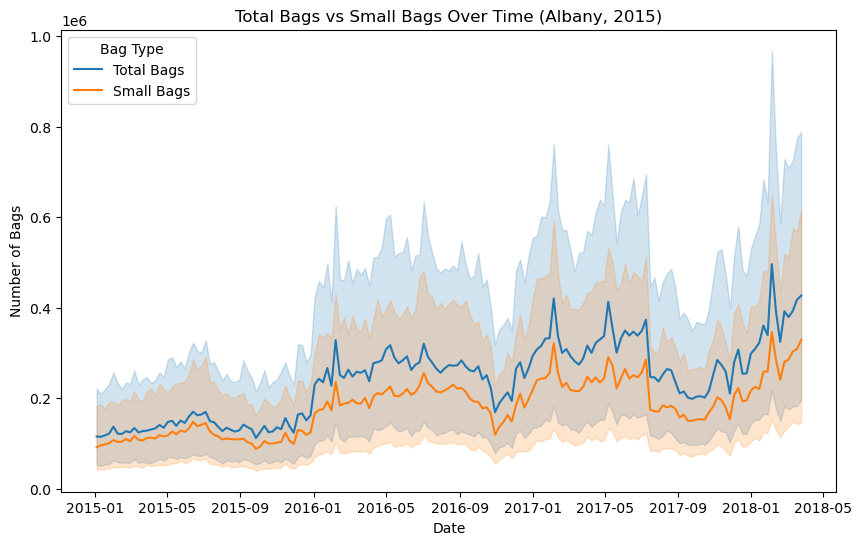

In [16]:
import seaborn as sns
#sns.lineplot(data = bag_melted, x = 'Count', y = 'Date', hue = 'Bags')
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # optional, just for readability

sns.lineplot(
    data=bag_melted,
    x='Date',
    y='Count',
    hue='Bags'   # distinguishes between Total Bags and Small Bags
)

plt.title('Total Bags vs Small Bags Over Time (Albany, 2015)')
plt.xlabel('Date')
plt.ylabel('Number of Bags')
plt.legend(title='Bag Type')
plt.show()

In [17]:
df['Volume quality'] = pd.qcut(df['Total Volume'], q=4,
                                       #bins =[0,4600,9200,13800,18400],
        labels=['poor', 'modest', 'good', 'excellent'])
df

,Date,Average Price,Total Volume,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,Volume quality
0,2015-12-27,1.33,64236.62,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,modest
1,2015-12-20,1.35,54876.98,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,modest
2,2015-12-13,0.93,118220.22,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,good
3,2015-12-06,1.08,78992.15,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,modest
4,2015-11-29,1.28,51039.60,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,modest
...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico,modest
18245,2018-01-28,1.71,13888.04,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico,modest
18246,2018-01-21,1.87,13766.76,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico,modest
18247,2018-01-14,1.93,16205.22,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico,modest


<Axes: xlabel='year', ylabel='count'>

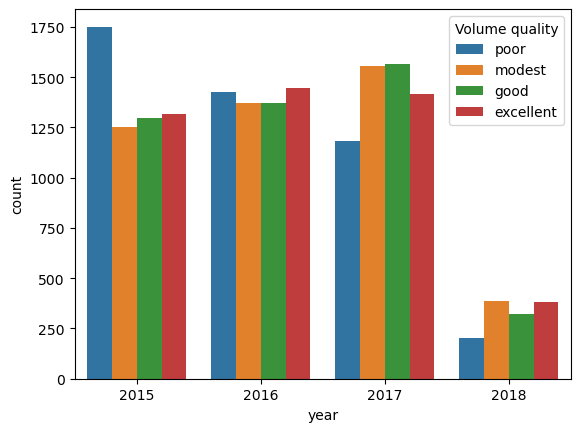

In [18]:
#sns.countplot(data = bag_melted,  y = 'Date')
sns.countplot(data=df, x='year', hue='Volume quality')

In [20]:
import matplotlib.pyplot as plt
bag_size_melted = pd.melt(df, id_vars = ['year'],
        value_vars =['Small Bags','Large Bags','XLarge Bags'],
        var_name='bagsizes', value_name = 'bagSizeValue')

bag_size_melted.head()


,year,bagsizes,bagSizeValue
0,2015,Small Bags,8603.62
1,2015,Small Bags,9408.07
2,2015,Small Bags,8042.21
3,2015,Small Bags,5677.40
4,2015,Small Bags,5986.26


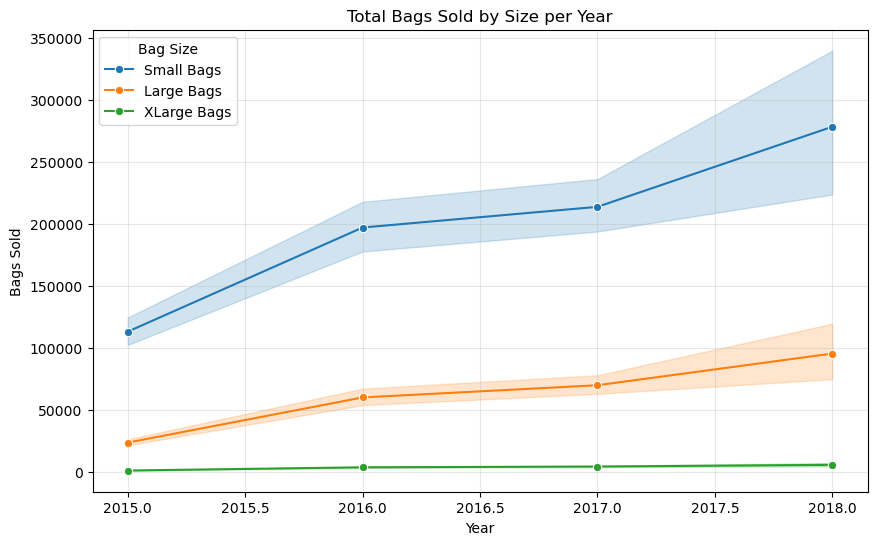

In [22]:
#sns.countplot(data=bag_size_melted, x='bagsizes', hue='year')
#sns.barplot(data=bag_size_melted, x='year', y='bagSizeValue', hue='bagsizes')
#plt.title('Bag Sales by Size per Year')
#plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize=(10,6))

sns.lineplot(
    data=bag_size_melted,
    x='year',
    y='bagSizeValue',
    hue='bagsizes',
    marker='o'
)

plt.title('Total Bags Sold by Size per Year')
plt.xlabel('Year')
plt.ylabel('Bags Sold')
plt.legend(title='Bag Size')
plt.grid(alpha=0.3)
plt.show()

In [25]:
type_sales = df.groupby('type')['Total Volume'].sum().reset_index()
type_sales

top_type = type_sales.sort_values('Total Volume', ascending=False).head(1)
top_type


,type,Total Volume
0,conventional,1.508722e+10


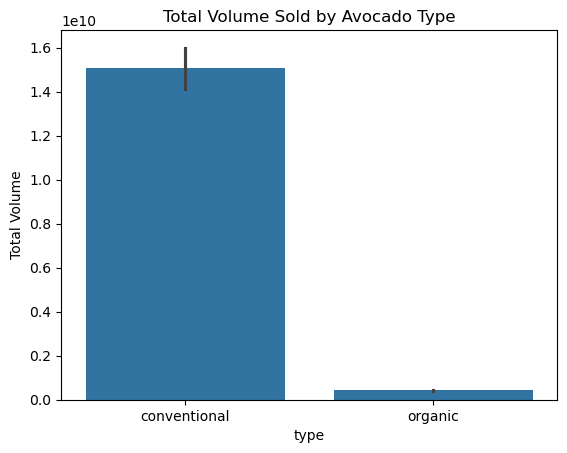

In [95]:
sns.barplot(data=df, x='type', y='Total Volume', estimator='sum')
plt.title('Total Volume Sold by Avocado Type')
plt.show()

In [96]:
print('conventional type of avacado sold the most')

conventional type of avacado sold the most
